<a href="https://colab.research.google.com/github/shammika000/sri-lanka-electricity-demand-forecasting/blob/main/ml/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/load_forecasting_dataset_corrected.csv')
df.head()


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


In [ ]:
df.shape

(189888, 15)

In [ ]:
df.columns

Index(['Timestamp', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
       'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)',
       'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)',
       'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event',
       'Load Demand (kW)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189888 entries, 0 to 189887
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Timestamp                    189888 non-null  object 
 1   Temperature (°C)             189888 non-null  float64
 2   Humidity (%)                 189888 non-null  float64
 3   Wind Speed (m/s)             189888 non-null  float64
 4   Rainfall (mm)                189888 non-null  float64
 5   Solar Irradiance (W/m²)      189888 non-null  float64
 6   GDP (LKR)                    189888 non-null  float64
 7   Per Capita Energy Use (kWh)  189888 non-null  float64
 8   Electricity Price (LKR/kWh)  189888 non-null  float64
 9   Day of Week                  189888 non-null  int64  
 10  Hour of Day                  189888 non-null  int64  
 11  Month                        189888 non-null  int64  
 12  Season                       189888 non-null  object 
 13 

In [ ]:
df.describe()

,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW)
count,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000
mean,28.001544,79.998447,1.996106,5.014217,249.938317,1000.083804,499.909985,24.998521,3.001011,11.500000,6.253286,0.049650,1500.154422
std,1.999267,5.002994,1.002337,5.016601,50.008961,50.015166,20.040060,4.998985,1.998741,6.922205,3.465723,0.217222,199.926679
min,19.068792,57.930570,-2.829436,0.000004,53.558277,779.558268,407.111625,3.268386,0.000000,0.000000,1.000000,0.000000,606.879227
25%,26.652234,76.621433,1.317979,1.435887,216.176066,966.274369,486.400599,21.623224,1.000000,5.750000,3.000000,0.000000,1365.223394
50%,28.002750,80.003040,1.995783,3.480060,249.871247,1000.001997,499.947457,25.010508,3.000000,11.500000,6.000000,0.000000,1500.274982
75%,29.350713,83.368748,2.673888,6.954906,283.683824,1033.802397,513.405061,28.376540,5.000000,17.250000,9.000000,0.000000,1635.071296
max,37.124229,101.096832,6.301848,59.219061,449.497275,1251.690264,592.327679,47.420391,6.000000,23.000000,12.000000,1.000000,2412.422945


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Temperature (°C),0
Humidity (%),0
Wind Speed (m/s),0
Rainfall (mm),0
Solar Irradiance (W/m²),0
GDP (LKR),0
Per Capita Energy Use (kWh),0
Electricity Price (LKR/kWh),0
Day of Week,0


In [ ]:
## 2. Data Understanding and Quality Checking

In [ ]:
df.columns.tolist()

['Timestamp',
 'Temperature (°C)',
 'Humidity (%)',
 'Wind Speed (m/s)',
 'Rainfall (mm)',
 'Solar Irradiance (W/m²)',
 'GDP (LKR)',
 'Per Capita Energy Use (kWh)',
 'Electricity Price (LKR/kWh)',
 'Day of Week',
 'Hour of Day',
 'Month',
 'Season',
 'Public Event',
 'Load Demand (kW)']

In [ ]:
#Convert Timestamp to proper date/time
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Timestamp'].dtype

dtype('<M8[ns]')

In [ ]:
print("Start date:", df['Timestamp'].min())
print("End date:", df['Timestamp'].max())

Start date: 2020-01-01 00:00:00
End date: 2025-05-31 23:45:00


In [ ]:
#Check whether timestamps are sorted
df['Timestamp'].is_monotonic_increasing

True

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Timestamp'].duplicated().sum()

np.int64(0)

In [ ]:
#Check the time interval
df['Timestamp'].diff().value_counts().head(10)

,count
Timestamp,
0 days 00:15:00,189887


In [ ]:
df['Season'].value_counts()

,count
Season,
Fall,96672
Summer,49056
Winter,44160


In [ ]:
df['Public Event'].value_counts()

,count
Public Event,
0,180460
1,9428


In [ ]:
df['Load Demand (kW)'].describe()

,Load Demand (kW)
count,189888.000000
mean,1500.154422
std,199.926679
min,606.879227
25%,1365.223394
50%,1500.274982
75%,1635.071296
max,2412.422945


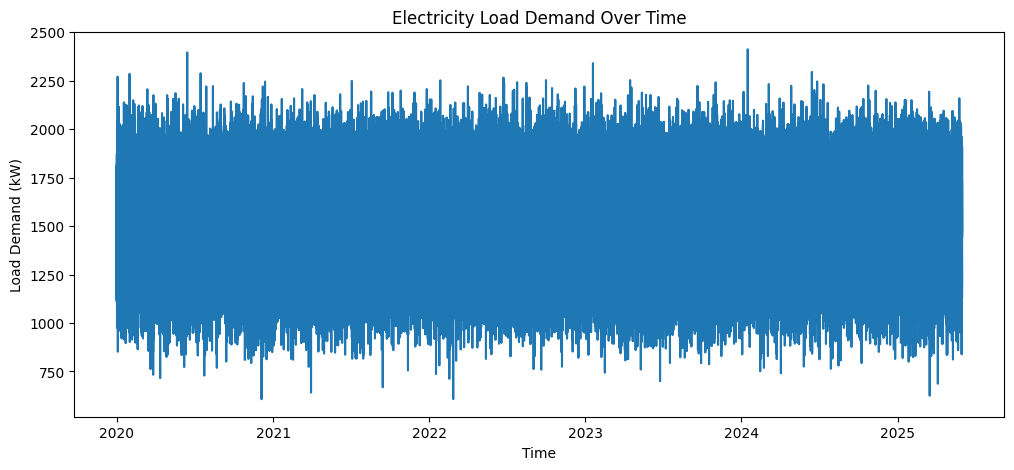

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df['Timestamp'], df['Load Demand (kW)'])

plt.title('Electricity Load Demand Over Time')
plt.xlabel('Time')
plt.ylabel('Load Demand (kW)')
plt.show()

In [ ]:
#Check for impossible values
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        column,
        "Min:", df[column].min(),
        "Max:", df[column].max()
    )

Temperature (°C) Min: 19.06879227 Max: 37.12422945
Humidity (%) Min: 57.93057017 Max: 101.0968317
Wind Speed (m/s) Min: -2.829436009 Max: 6.301847743
Rainfall (mm) Min: 4.16e-06 Max: 59.21906086
Solar Irradiance (W/m²) Min: 53.55827665 Max: 449.4972747
GDP (LKR) Min: 779.5582682 Max: 1251.690264
Per Capita Energy Use (kWh) Min: 407.1116245 Max: 592.3276785
Electricity Price (LKR/kWh) Min: 3.268386481 Max: 47.4203905
Day of Week Min: 0 Max: 6
Hour of Day Min: 0 Max: 23
Month Min: 1 Max: 12
Public Event Min: 0 Max: 1
Load Demand (kW) Min: 606.8792273 Max: 2412.422945
